# Visualization: Convexity and Network-Constrained SPCA Objectives

This notebook provides interactive visualizations to understand:
1. **Quadratic Forms**: How the eigenvalues of matrix $A$ determine the convexity/concavity of $f(x) = x^\top A x$.
2. **SPCA Objectives**: How Sparsity ($\ell_1$) and Network Constraints (Laplacian) alter the PCA optimization landscape.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# Set nicer plotting defaults
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12

## Part 1: Convexity of Quadratic Forms

We visualize the quadratic form $Q(x) = x^\top A x$ for $x \in \mathbb{R}^2$. 
According to spectral theory:
- If $A \succ 0$ (eigenvalues > 0), $Q(x)$ is **Strictly Convex** (Bowl).
- If $A \prec 0$ (eigenvalues < 0), $Q(x)$ is **Strictly Concave** (Inverted Bowl).
- If $A$ has mixed eigenvalues, $Q(x)$ is a **Saddle Point** (Nonconvex).

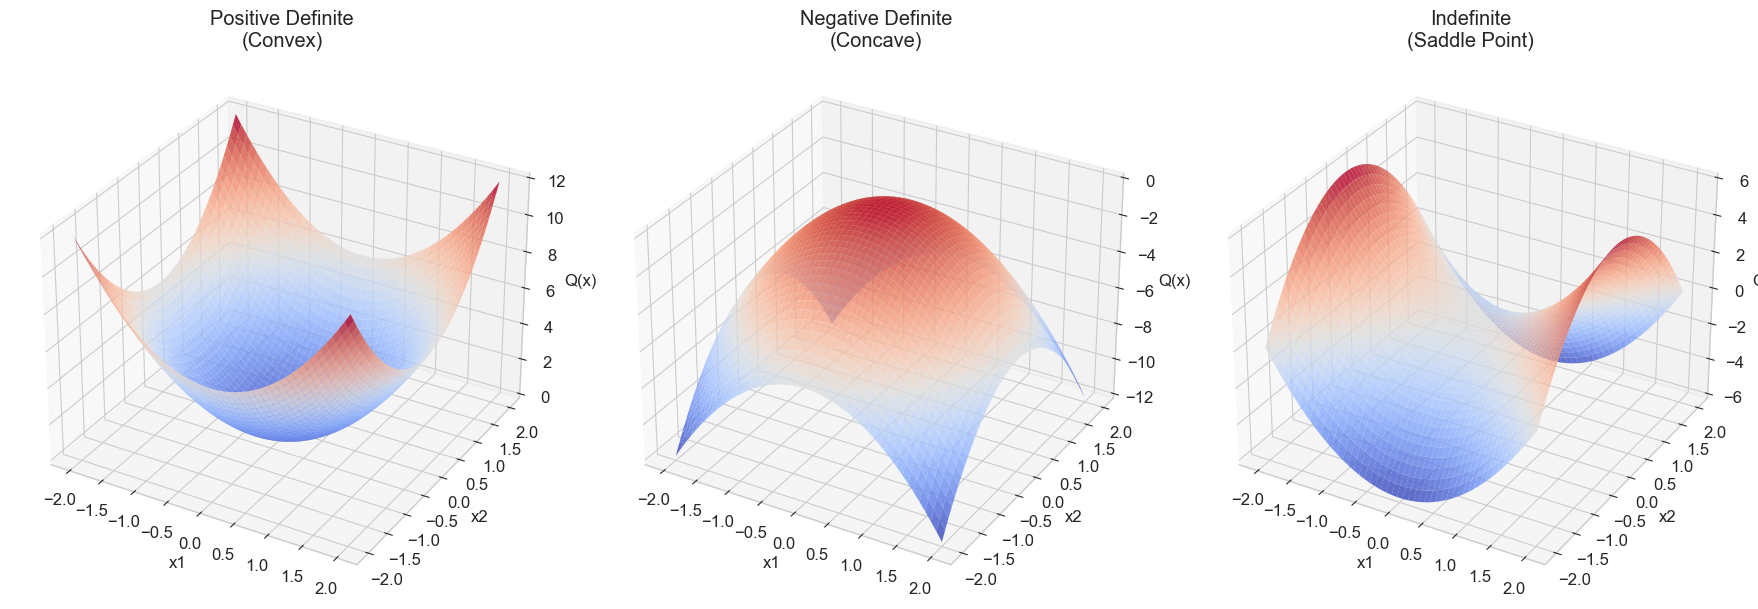

In [6]:
def plot_quadratic_form(A, title, ax):
    """Plots the surface z = x.T @ A @ x"""
    x = np.linspace(-2, 2, 50)
    y = np.linspace(-2, 2, 50)
    X, Y = np.meshgrid(x, y)
    
    # Compute Z values
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            vec = np.array([X[i,j], Y[i,j]])
            Z[i,j] = vec.T @ A @ vec
            
    surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, 
                           linewidth=0, antialiased=True, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('Q(x)')

# Define matrices
A_convex = np.array([[1.5, 0], [0, 1.5]])      # Positive Definite
A_concave = np.array([[-1.5, 0], [0, -1.5]])   # Negative Definite
A_saddle = np.array([[1.5, 0], [0, -1.5]])     # Indefinite

# Create plot
fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(131, projection='3d')
plot_quadratic_form(A_convex, "Positive Definite\n(Convex)", ax1)

ax2 = fig.add_subplot(132, projection='3d')
plot_quadratic_form(A_concave, "Negative Definite\n(Concave)", ax2)

ax3 = fig.add_subplot(133, projection='3d')
plot_quadratic_form(A_saddle, "Indefinite\n(Saddle Point)", ax3)

plt.tight_layout()
plt.show()

## Part 2: The Network-Constrained SPCA Landscape

The optimization problem is:
 HHHH$$ \max_{\ \|w\ \|_2 \le 1} \quad w^\top \Sigma w - \lambda_1 \|w\|_1 - \lambda_2 w^\top L w$$

We simulate a 2D scenario where:
1. **Variance ($\ \Sigma$)**: The data varies most along the anti-diagonal ($x_1 = -x_2$).
2. **Graph Smoothness ($L$)**: A 2-node graph connects features 1 and 2, preferring $x_1 = x_2$.
3. **Sparsity ($\ \ell_1$)**: Prefers axes $x_1=0$ or $x_2=0$.

This creates a tension between three distinct directions.

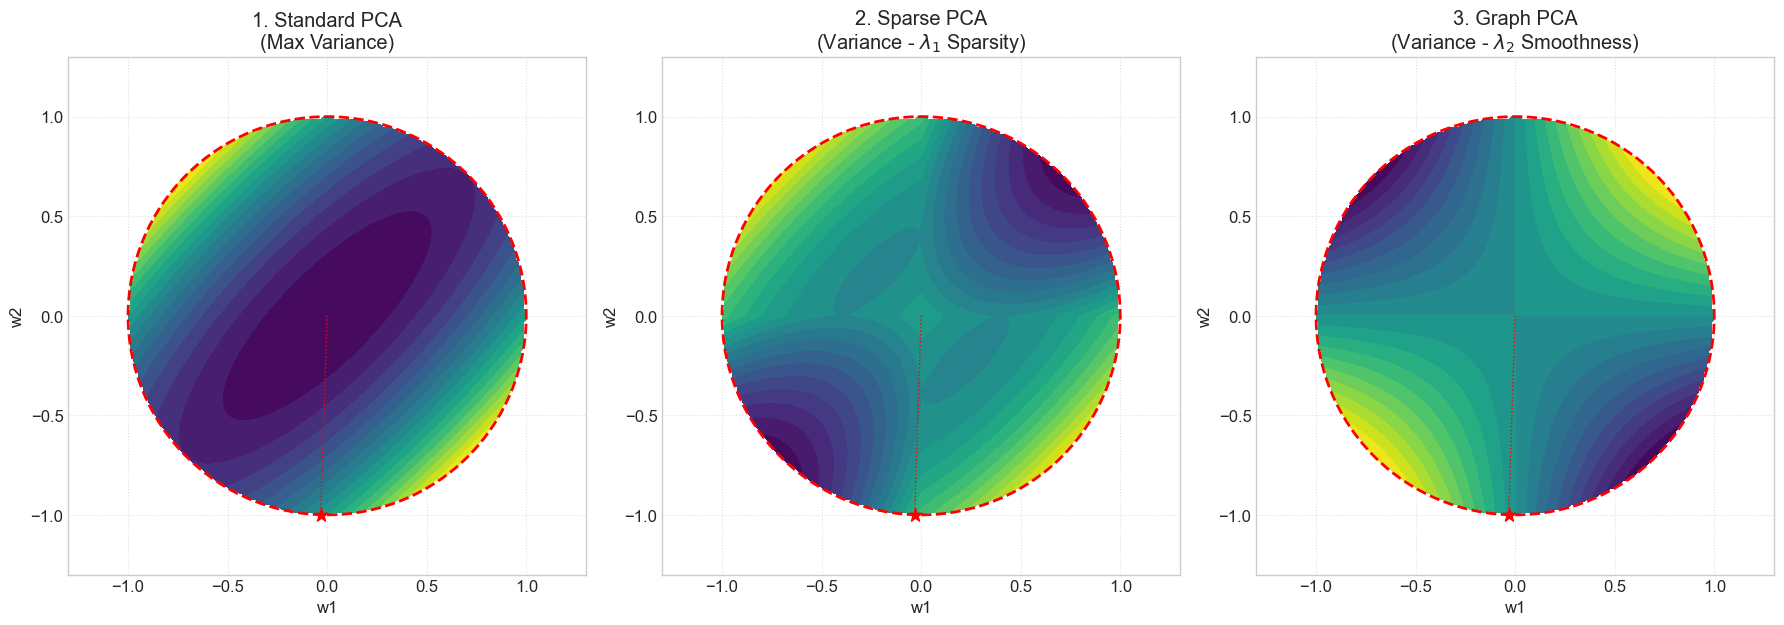

In [7]:
def plot_spca_objective(Sigma, lambda1, lambda2, title, ax):
    """Plots contours of the SPCA objective function."""
    
    # 1. Define Grid
    bound = 1.3
    x = np.linspace(-bound, bound, 200)
    y = np.linspace(-bound, bound, 200)
    X, Y = np.meshgrid(x, y)
    
    # 2. Define Laplacian for 2 nodes connected by an edge
    # L = D - A = [[1, -1], [-1, 1]]
    L = np.array([[1, -1], [-1, 1]])
    
    # 3. Compute Objective Z
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            w = np.array([X[i,j], Y[i,j]])
            
            # Variance term: w^T Sigma w
            variance = w.T @ Sigma @ w
            
            # Sparsity term: L1 norm
            sparsity = np.sum(np.abs(w))
            
            # Graph term: w^T L w = (w1 - w2)^2
            smoothness = w.T @ L @ w
            
            # Total Objective (Maximization form)
            Z[i,j] = variance - lambda1 * sparsity - lambda2 * smoothness
            
            # Mask values outside the unit ball for clarity (optional, but helps visualization)
            if np.linalg.norm(w) > 1:
                 Z[i,j] = np.nan # Or set to a low value

    # 4. Plot Contours
    contour = ax.contourf(X, Y, Z, 20, cmap='viridis')
    
    # 5. Draw Constraints (Unit Circle)
    circle = plt.Circle((0, 0), 1, color='red', fill=False, linestyle='--', linewidth=2, label='||w||_2 = 1')
    ax.add_artist(circle)
    
    # 6. Find and plot the maximum on the grid
    # (Naive search on the grid for visualization purposes)
    valid_mask = (X**2 + Y**2) <= 1.001
    Z_valid = np.where(valid_mask, Z, -np.inf)
    max_idx = np.unravel_index(np.argmax(Z_valid), Z_valid.shape)
    max_w = (X[max_idx], Y[max_idx])
    
    ax.scatter(max_w[0], max_w[1], c='red', s=100, marker='*', label='Optimum')
    ax.plot([0, max_w[0]], [0, max_w[1]], 'r:', linewidth=1)

    ax.set_title(title)
    ax.set_aspect('equal')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlabel('w1')
    ax.set_ylabel('w2')

# --- Setup Scenario ---
# Covariance with strong anti-correlation.
# Principal component is at [1, -1] (Anti-diagonal).
Sigma = np.array([[1, -0.8], [-0.8, 1]])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Case 1: Pure PCA (No penalty)
# Optimum should be at [1, -1] (normalized)
plot_spca_objective(Sigma, lambda1=0, lambda2=0, 
                   title="1. Standard PCA\n(Max Variance)", ax=axes[0])

# Case 2: Sparse PCA (L1 penalty)
# Optimum should shift towards axes (Sparse)
plot_spca_objective(Sigma, lambda1=0.8, lambda2=0, 
                   title="2. Sparse PCA\n(Variance - $\lambda_1$ Sparsity)", ax=axes[1])

# Case 3: Network Constrained PCA (Graph penalty)
# Graph connects nodes 1-2, enforcing w1 ~ w2.
# Optimum should shift towards [1, 1] (Diagonal), conflicting with Variance.
plot_spca_objective(Sigma, lambda1=0, lambda2=1.0, 
                   title="3. Graph PCA\n(Variance - $\lambda_2$ Smoothness)", ax=axes[2])

plt.tight_layout()
plt.show()

### Interpretation of Part 2

1.  **Standard PCA**: The optimum (Red Star) lies on the anti-diagonal ($w_1 = -w_2$). This is the direction of maximum variance for our chosen $\Sigma$.
2.  **Sparse PCA**: With $\lambda_1 > 0$, the contours become "diamond-shaped" (characteristic of $\ell_1$). The optimum is pulled away from the anti-diagonal towards the vertical axis ($w_1=0$), promoting sparsity.
3.  **Graph PCA**: With $\lambda_2 > 0$, the penalty $-w^\top L w = -(w_1-w_2)^2$ penalizes differences. This forces the solution towards the diagonal ($w_1=w_2$), directly opposing the variance term which wants $w_1 = -w_2$. The result is a compromise.

## Part 3: 3D Visualization of SPCA Objectives

Here we visualize the objective function surface in 3D over the unit disk ($||w||_2 \le 1$).
The height $z$ represents the objective value we want to maximize.

We compare 4 cases:
1. **Standard PCA**: Smooth quadratic bowl (saddle-like here due to indefinite terms).
2. **Sparse PCA**: Note the sharp "creases" along the axes ($w_1=0, w_2=0$) due to the $\ell_1$ non-differentiability.
3. **Graph PCA**: The surface bends to punish the anti-diagonal, creating a ridge along $w_1=w_2$.
4. **Combined (Net-SPCA)**: Both sparsity creases and graph smoothness shaping apply.

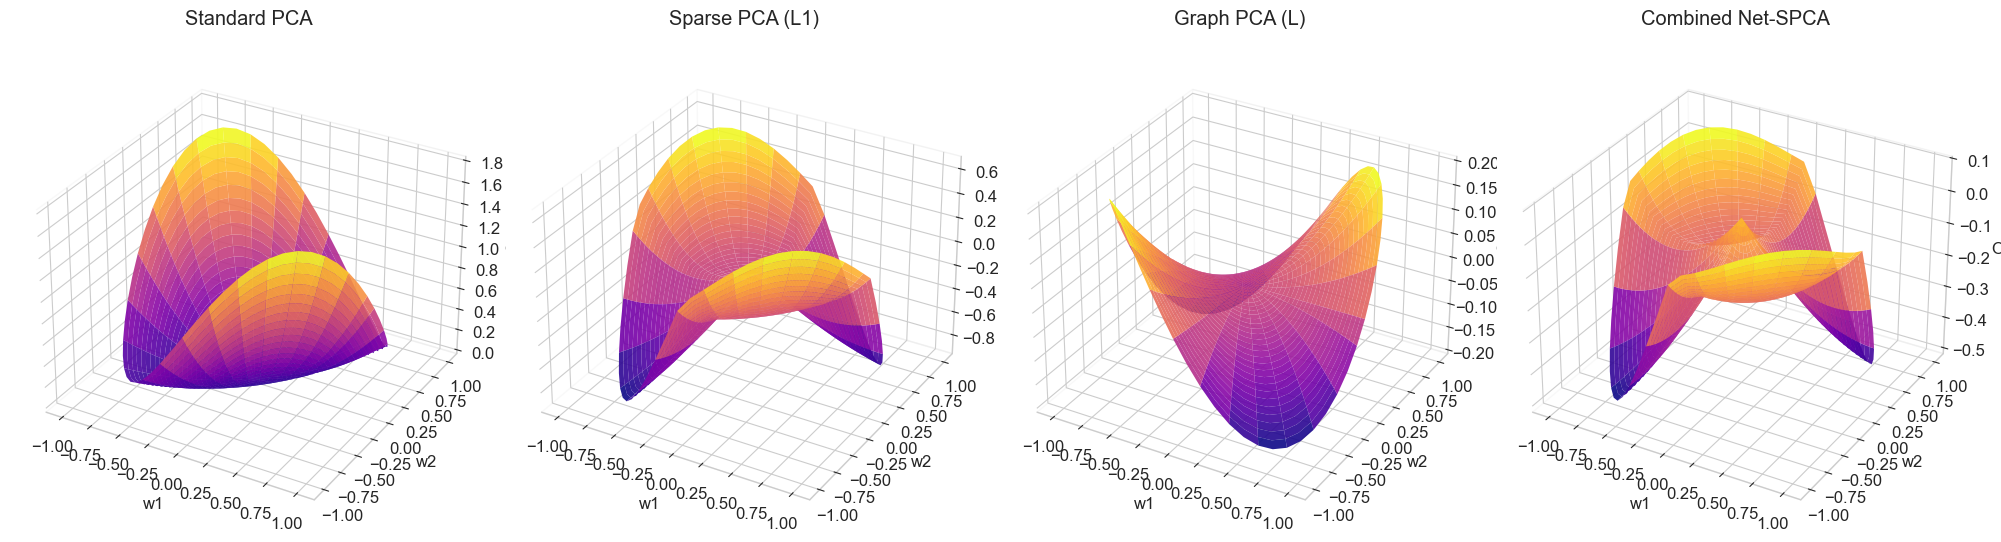

In [8]:
def plot_spca_3d(Sigma, lambda1, lambda2, title, ax):
    """Plots the 3D surface of the SPCA objective."""
    
    # 1. Define Grid (Unit Ball)
    r = np.linspace(0, 1, 30)
    theta = np.linspace(0, 2*np.pi, 60)
    R, Theta = np.meshgrid(r, theta)
    X = R * np.cos(Theta)
    Y = R * np.sin(Theta)
    
    # L = [[1, -1], [-1, 1]]
    L = np.array([[1, -1], [-1, 1]])
    
    # 2. Compute Z
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            w = np.array([X[i,j], Y[i,j]])
            variance = w.T @ Sigma @ w
            sparsity = np.sum(np.abs(w))
            smoothness = w.T @ L @ w
            Z[i,j] = variance - lambda1 * sparsity - lambda2 * smoothness

    # 3. Plot
    surf = ax.plot_surface(X, Y, Z, cmap='plasma', alpha=0.9, 
                           linewidth=0.2, antialiased=True)
    ax.set_title(title, pad=20)
    ax.set_xlabel('w1')
    ax.set_ylabel('w2')
    ax.set_zlabel('Obj')
    # Remove panes for cleaner look
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

# Setup
Sigma = np.array([[1, -0.8], [-0.8, 1]])
fig = plt.figure(figsize=(20, 6))

# 1. Standard
ax1 = fig.add_subplot(141, projection='3d')
plot_spca_3d(Sigma, 0, 0, "Standard PCA", ax1)

# 2. Sparse
ax2 = fig.add_subplot(142, projection='3d')
plot_spca_3d(Sigma, 0.8, 0, "Sparse PCA (L1)", ax2)

# 3. Graph
ax3 = fig.add_subplot(143, projection='3d')
plot_spca_3d(Sigma, 0, 1.0, "Graph PCA (L)", ax3)

# 4. Combined
ax4 = fig.add_subplot(144, projection='3d')
plot_spca_3d(Sigma, 0.5, 0.5, "Combined Net-SPCA", ax4)

plt.tight_layout()
plt.show()